In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

connection=sqlite3.connect('../data/checking-logs.sqlite')

In [40]:
df = pd.read_sql(sql=
"""
SELECT 
    strftime('%H', timestamp) AS hour,
    CASE 
        WHEN strftime('%w', timestamp) IN ('0', '6') THEN 'weekend'
        ELSE 'working_day'
    END AS day_type
FROM checker
WHERE uid LIKE 'user_%'
""", con=connection)
df

,hour,day_type
0,05,working_day
1,05,working_day
2,05,working_day
3,05,working_day
4,05,working_day
...,...,...
3202,20,working_day
3203,20,working_day
3204,20,working_day
3205,20,working_day


In [41]:
working_days = df[df['day_type'] == 'working_day']['hour'].astype(int).tolist()
weekends = df[df['day_type'] == 'weekend']['hour'].astype(int).tolist()

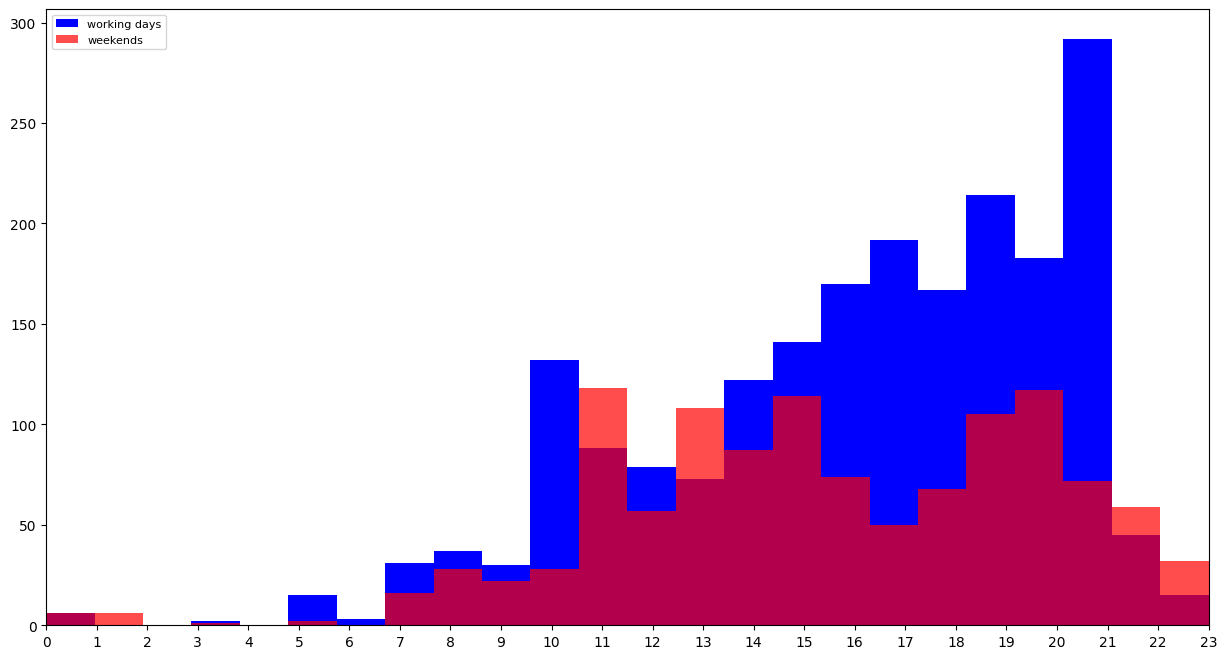

In [45]:
plt.figure(figsize=(15, 8))

plt.hist(working_days, bins=24, label='working days', color="blue")
plt.hist(weekends, bins=24, alpha=0.7, label='weekends', color="red")
plt.legend(loc='upper left', fontsize=8)

plt.xlim(0, 23)
plt.xticks(range(0, 24))

plt.show()

In [38]:
connection.close()

Are there hours when the total number of commits was higher on weekends than on working days? In your answer, include the top four examples.  

**11,13,22,23**